# Tuần 03 — Ngữ pháp đồ họa và Điều kiện hóa qua Teamfight Tactics

**UET.MAT1052 — Xác suất thống kê**  
**ThS. Hoàng Hữu Bách — BM. Khoa học & Kỹ thuật tính toán - Khoa Công nghệ Thông tin, VNU-UET**  
**Thực hành chính thức bằng Python**

---

Trong notebook này, mọi ví dụ đều đặt trong bối cảnh **Teamfight Tactics (TFT)**. Ta sẽ không học cách chọn đội hình “meta”, mà dùng dữ liệu TFT để học cách đặt câu hỏi, thiết kế biểu đồ, lọc, nhóm và nhận ra khi số liệu gộp che mất cấu trúc quan trọng.

Sau tuần này, bạn cần làm được:

1. Phân tích một biểu đồ thành **dữ liệu**, **ánh xạ thuộc tính hình ảnh**, **dạng hình học** và **nhóm**.
2. Phân biệt *ánh xạ* một thuộc tính theo biến với *thiết lập* một giá trị cố định.
3. Chọn dạng hình học phù hợp với câu hỏi và đơn vị quan sát.
4. Lọc dữ liệu bằng các phép so sánh, “và”, “hoặc” và `.isin()`.
5. Đọc một pipeline pandas như một lập luận; phân biệt lọc với nhóm.
6. Nhóm rồi tóm tắt; so sánh tỉ lệ gộp với tỉ lệ có điều kiện.
7. Giải thích một nghịch lý Simpson bằng cơ chế trọng số.

> **Lưu ý về dữ liệu.** Toàn bộ dữ liệu trong notebook được mô phỏng có chủ đích cho việc học thống kê. Đây không phải dữ liệu từ Riot Games, không phản ánh một patch cụ thể và không dùng để kết luận đội hình nào mạnh trong game thật. Các khái niệm ổn định như placement, top 4, vàng, máu, cấp độ, reroll và nhịp lobby được dùng làm bối cảnh.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import display

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

plt.style.use("seaborn-v0_8-whitegrid")
rng = np.random.default_rng(202503)

BAC = ["Bạc", "Vàng", "Bạch Kim", "Kim Cương"]
CHIEN_THUAT = ["Reroll cấp 6", "Tempo cấp 7", "Fast 8"]
LOI = ["Kinh tế", "Giao tranh", "Linh hoạt"]

MAU_CHIEN_THUAT = {
    "Reroll cấp 6": "#E69F00",
    "Tempo cấp 7": "#56B4E9",
    "Fast 8": "#009E73",
}


In [2]:
# Tạo 120 lobby, mỗi lobby có đúng 8 người chơi và đủ placement từ 1 đến 8.
rows = []
so_lobby = 120

bac_skill = {"Bạc": -0.35, "Vàng": 0.00, "Bạch Kim": 0.30, "Kim Cương": 0.60}
scout_base = {"Bạc": 1.2, "Vàng": 2.0, "Bạch Kim": 3.0, "Kim Cương": 4.2}

# Roster cố định: mỗi player thuộc đúng một bậc và không thể xuất hiện hai lần
# trong cùng lobby. Kỹ năng có thành phần ổn định theo player và dao động theo trận.
player_pools = {}
player_skill = {}
player_no = 1
for bac_roster in BAC:
    ids = [f"P{i:03d}" for i in range(player_no, player_no + 60)]
    player_pools[bac_roster] = ids
    for player_id in ids:
        player_skill[player_id] = bac_skill[bac_roster] + rng.normal(0, 0.45)
    player_no += 60

for lobby_no in range(1, so_lobby + 1):
    bac = rng.choice(BAC, p=[0.20, 0.35, 0.30, 0.15])
    p_nhanh = {"Bạc": 0.30, "Vàng": 0.42, "Bạch Kim": 0.58, "Kim Cương": 0.72}[bac]
    nhip_lobby = rng.choice(["Chậm", "Nhanh"], p=[1 - p_nhanh, p_nhanh])
    nguoi_choi_lobby = rng.choice(player_pools[bac], size=8, replace=False)

    lobby_rows = []
    for player_id in nguoi_choi_lobby:
        if nhip_lobby == "Chậm":
            p_chien_thuat = [0.45, 0.35, 0.20]
        else:
            p_chien_thuat = [0.20, 0.45, 0.35]

        chien_thuat = rng.choice(CHIEN_THUAT, p=p_chien_thuat)
        loi = rng.choice(LOI, p=[0.34, 0.43, 0.23])
        ky_nang = player_skill[player_id] + rng.normal(0, 0.35)

        cap_co_so = {"Reroll cấp 6": 6, "Tempo cấp 7": 7, "Fast 8": 8}[chien_thuat]
        cap_4_1 = int(np.clip(cap_co_so + rng.choice([-1, 0, 0, 0, 1]), 5, 9))

        roll_base = {"Reroll cấp 6": 34, "Tempo cấp 7": 19, "Fast 8": 8}[chien_thuat]
        so_lan_roll = int(np.clip(rng.normal(roll_base, 7), 0, 55))

        vang_base = {"Reroll cấp 6": 18, "Tempo cấp 7": 31, "Fast 8": 48}[chien_thuat]
        vang_4_1 = int(np.clip(rng.normal(vang_base, 10), 0, 80))

        mau_bonus = {"Reroll cấp 6": -2, "Tempo cấp 7": 6, "Fast 8": -5}[chien_thuat]
        if nhip_lobby == "Nhanh":
            mau_bonus -= 7
        mau_4_1 = int(np.clip(rng.normal(55 + mau_bonus + 7 * ky_nang, 15), 1, 100))

        so_tuong_3_sao = int(
            rng.poisson({"Reroll cấp 6": 1.55, "Tempo cấp 7": 0.55, "Fast 8": 0.20}[chien_thuat])
        )
        so_lan_scout = int(rng.poisson(scout_base[bac] + max(ky_nang, -0.5)))

        gia_tri_doi_hinh = (
            8
            + 2.8 * cap_4_1
            + 0.26 * so_lan_roll
            + 4.5 * so_tuong_3_sao
            + rng.normal(0, 4)
        )

        # Hiệu quả chiến thuật phụ thuộc nhịp lobby: đây là chủ đích của DGP mô phỏng.
        hieu_qua = {
            ("Chậm", "Reroll cấp 6"): 0.45,
            ("Chậm", "Tempo cấp 7"): 0.20,
            ("Chậm", "Fast 8"): 0.00,
            ("Nhanh", "Reroll cấp 6"): -0.35,
            ("Nhanh", "Tempo cấp 7"): 0.25,
            ("Nhanh", "Fast 8"): 0.50,
        }[(nhip_lobby, chien_thuat)]

        diem_hieu_suat = (
            1.25 * ky_nang
            + hieu_qua
            + 0.035 * mau_4_1
            + 0.020 * vang_4_1
            + 0.025 * gia_tri_doi_hinh
            + 0.055 * so_lan_scout
            + (0.18 if loi == "Giao tranh" and nhip_lobby == "Nhanh" else 0)
            + rng.normal(0, 0.85)
        )

        lobby_rows.append(
            {
                "lobby_id": f"L{lobby_no:03d}",
                "player_id": player_id,
                "bac_xep_hang": bac,
                "nhip_lobby": nhip_lobby,
                "chien_thuat": chien_thuat,
                "loai_loi": loi,
                "mau_4_1": mau_4_1,
                "vang_4_1": vang_4_1,
                "cap_4_1": cap_4_1,
                "so_lan_roll": so_lan_roll,
                "so_tuong_3_sao": so_tuong_3_sao,
                "so_lan_scout": so_lan_scout,
                "gia_tri_doi_hinh": round(gia_tri_doi_hinh, 1),
                "_diem_hieu_suat": diem_hieu_suat,
            }
        )

    # Người có điểm hiệu suất lớn nhất đứng hạng 1.
    thu_tu = np.argsort([-r["_diem_hieu_suat"] for r in lobby_rows])
    for placement, idx in enumerate(thu_tu, start=1):
        lobby_rows[idx]["placement"] = placement
        lobby_rows[idx]["top4"] = placement <= 4
        lobby_rows[idx]["win"] = placement == 1
        lobby_rows[idx]["sat_thuong_nguoi_choi"] = int(
            np.clip(118 - 10 * placement + rng.normal(0, 12), 15, 150)
        )
        del lobby_rows[idx]["_diem_hieu_suat"]
        rows.append(lobby_rows[idx])

tran_tft = pd.DataFrame(rows)
tran_tft["bac_xep_hang"] = pd.Categorical(
    tran_tft["bac_xep_hang"], categories=BAC, ordered=True
)
tran_tft["chien_thuat"] = pd.Categorical(
    tran_tft["chien_thuat"], categories=CHIEN_THUAT, ordered=True
)
tran_tft["loai_loi"] = pd.Categorical(
    tran_tft["loai_loi"], categories=LOI, ordered=True
)

# Hai biến bổ sung cho bài học về thang đo và dữ liệu thiếu.
# Tổng sát thương có đuôi phải dài; telemetry scout cố ý thiếu ở 4% số hàng.
tran_tft["tong_sat_thuong"] = np.rint(
    np.exp(rng.normal(10.2 + 0.035 * (9 - tran_tft["placement"]), 0.62))
).astype(int)
chi_so_thieu = rng.choice(
    tran_tft.index, size=round(0.04 * len(tran_tft)), replace=False
)
tran_tft.loc[chi_so_thieu, "so_lan_scout"] = np.nan

# Lịch sử 30 trận liên tiếp của một người chơi giả định.
so_tran = 30
xu_huong = np.linspace(0.15, -0.55, so_tran)
placement_lich_su = np.clip(
    np.rint(4.8 + xu_huong + rng.normal(0, 1.85, so_tran)), 1, 8
).astype(int)
lich_su = pd.DataFrame(
    {
        "tran_thu": np.arange(1, so_tran + 1),
        "placement": placement_lich_su,
        "chien_thuat": rng.choice(CHIEN_THUAT, size=so_tran, p=[0.32, 0.40, 0.28]),
    }
)
lich_su["top4"] = lich_su["placement"] <= 4
lich_su["placement_tb_5_tran"] = lich_su["placement"].rolling(5, min_periods=1).mean()

print(f"Số lobby: {tran_tft['lobby_id'].nunique()}")
print(f"Số quan sát người-chơi–trận: {len(tran_tft)}")
tran_tft[tran_tft['player_id']=="P044"]


Số lobby: 120
Số quan sát người-chơi–trận: 960


,lobby_id,player_id,bac_xep_hang,nhip_lobby,chien_thuat,loai_loi,mau_4_1,vang_4_1,cap_4_1,so_lan_roll,so_tuong_3_sao,so_lan_scout,gia_tri_doi_hinh,placement,top4,win,sat_thuong_nguoi_choi,tong_sat_thuong
0,L001,P044,Bạc,Chậm,Reroll cấp 6,Giao tranh,38,12,6,28,1,2.000,36.700,1,True,True,127,40681
304,L039,P044,Bạc,Chậm,Fast 8,Linh hoạt,30,40,8,9,0,0.000,32.800,1,True,True,134,51296
410,L052,P044,Bạc,Chậm,Reroll cấp 6,Kinh tế,59,22,7,41,1,0.000,41.000,3,True,False,103,34853
888,L112,P044,Bạc,Chậm,Reroll cấp 6,Giao tranh,47,14,7,42,1,2.000,44.600,1,True,True,111,89546


## Khởi động: đọc cấu trúc dữ liệu trước khi vẽ

Mỗi hàng của `tran_tft` là **một người chơi trong một trận**. Đây không phải một tướng, một ô trên bàn hay toàn bộ lobby.

| Biến | Ý nghĩa |
|---|---|
| `lobby_id`, `player_id` | mã lobby và người chơi giả định |
| `bac_xep_hang` | Bạc, Vàng, Bạch Kim hoặc Kim Cương |
| `nhip_lobby` | lobby chậm hoặc nhanh |
| `chien_thuat` | Reroll cấp 6, Tempo cấp 7 hoặc Fast 8 |
| `mau_4_1`, `vang_4_1`, `cap_4_1` | trạng thái tại stage 4-1 |
| `so_lan_roll`, `so_tuong_3_sao`, `so_lan_scout` | hành vi hoặc kết quả trong trận; telemetry scout có một số giá trị thiếu |
| `tong_sat_thuong` | tổng sát thương trong trận; phân phối có đuôi phải dài |
| `placement` | thứ hạng cuối trận; **số nhỏ hơn là tốt hơn** |
| `top4`, `win` | biến logic cho top 4 và hạng nhất |

> **W03-TFT-Q00.** Nếu muốn nghiên cứu “mỗi lobby có bao nhiêu người chơi Fast 8?”, đơn vị quan sát cuối cùng của bảng kết quả là gì? Nếu muốn nghiên cứu “mỗi người chơi có tỉ lệ top 4 bao nhiêu qua nhiều trận?”, cần nhóm theo biến nào?

<details><summary>Đáp án</summary>

- Câu hỏi thứ nhất cần một hàng cho mỗi lobby.
- Câu hỏi thứ hai cần nhóm theo `player_id`; một hàng người-chơi–trận chưa phải tỉ lệ dài hạn của một người chơi.

</details>


In [3]:
# Ba kiểm tra nhỏ để xác nhận DGP mô phỏng tạo đúng cấu trúc.
kiem_tra_placement = tran_tft.groupby("lobby_id")["placement"].agg(["min", "max", "nunique"])
assert (kiem_tra_placement["min"] == 1).all()
assert (kiem_tra_placement["max"] == 8).all()
assert (kiem_tra_placement["nunique"] == 8).all()
assert tran_tft["top4"].mean() == 0.5
assert not tran_tft.duplicated(["lobby_id", "player_id"]).any()
assert tran_tft.groupby("player_id", observed=True)["bac_xep_hang"].nunique().max() == 1

tran_tft.describe(include="all").T[
    ["count", "unique", "mean", "min", "max"]
].fillna("")


,count,unique,mean,min,max
lobby_id,960,120,,,
player_id,960,229,,,
bac_xep_hang,960,4,,,
nhip_lobby,960,2,,,
chien_thuat,960,3,,,
loai_loi,960,3,,,
mau_4_1,960.000,,52.173,1.000,100.000
vang_4_1,960.000,,31.264,0.000,76.000
cap_4_1,960.000,,7.008,5.000,9.000
so_lan_roll,960.000,,20.336,0.000,53.000


---
## Phần 1. Ngữ pháp đồ họa (Grammar of Graphics)

### 1.1 Những biểu đồ TFT trông rất khác nhau

Bốn biểu đồ dưới đây cùng dùng bảng `tran_tft`, nhưng mỗi biểu đồ trả lời một câu hỏi khác.


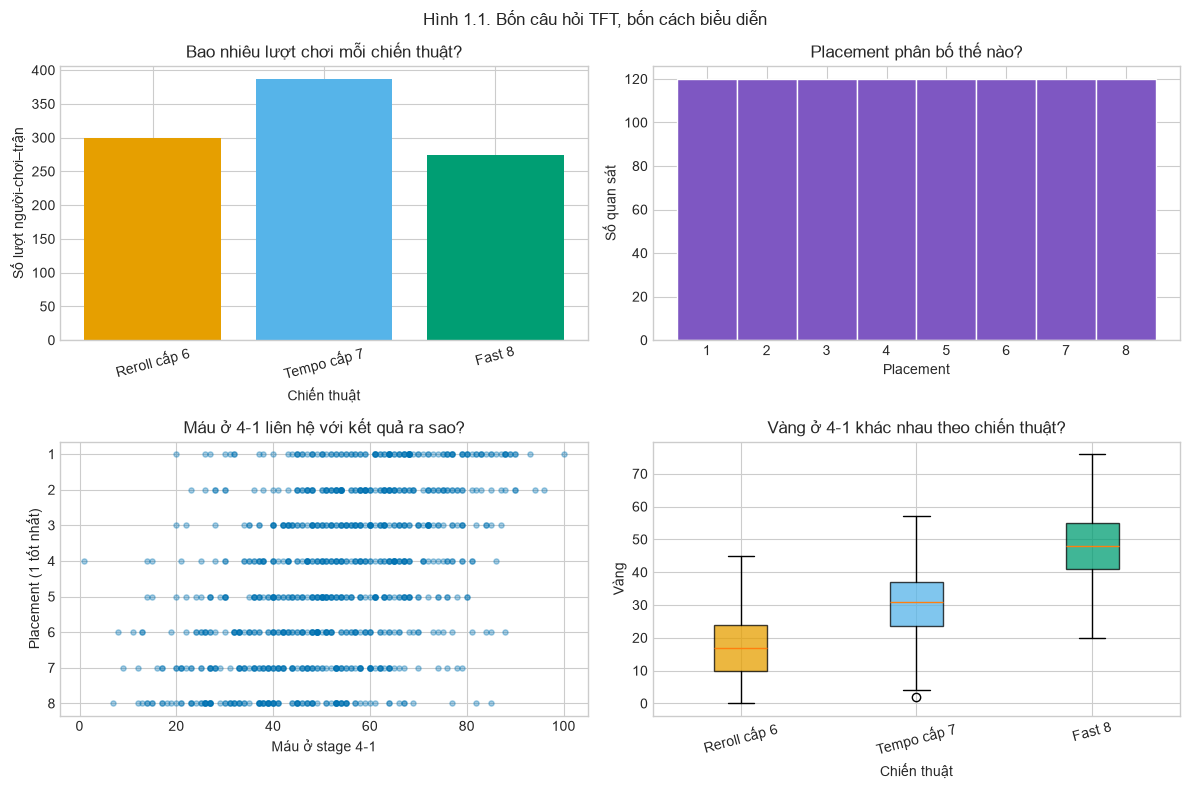

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# (1) Số trận theo chiến thuật
dem = tran_tft["chien_thuat"].value_counts(sort=False)
axes[0, 0].bar(dem.index.astype(str), dem.values,
               color=[MAU_CHIEN_THUAT[x] for x in CHIEN_THUAT])
axes[0, 0].set(title="Bao nhiêu lượt chơi mỗi chiến thuật?",
               xlabel="Chiến thuật", ylabel="Số lượt người-chơi–trận")
axes[0, 0].tick_params(axis="x", rotation=15)

# (2) Phân phối placement
axes[0, 1].hist(tran_tft["placement"], bins=np.arange(0.5, 9.5, 1),
                color="#7E57C2", edgecolor="white")
axes[0, 1].set(title="Placement phân bố thế nào?",
               xlabel="Placement", ylabel="Số quan sát", xticks=range(1, 9))

# (3) Máu stage 4-1 và placement
axes[1, 0].scatter(tran_tft["mau_4_1"], tran_tft["placement"],
                   s=14, alpha=0.35, color="#0072B2")
axes[1, 0].invert_yaxis()
axes[1, 0].set(title="Máu ở 4-1 liên hệ với kết quả ra sao?",
               xlabel="Máu ở stage 4-1", ylabel="Placement (1 tốt nhất)")

# (4) Vàng ở 4-1 theo chiến thuật
nhom_vang = [
    tran_tft.loc[tran_tft["chien_thuat"] == c, "vang_4_1"] for c in CHIEN_THUAT
]
axes[1, 1].boxplot(nhom_vang, patch_artist=True)
axes[1, 1].set_xticks(range(1, len(CHIEN_THUAT) + 1))
axes[1, 1].set_xticklabels(CHIEN_THUAT)
for patch, c in zip(axes[1, 1].patches, [MAU_CHIEN_THUAT[x] for x in CHIEN_THUAT]):
    patch.set_facecolor(c)
    patch.set_alpha(0.75)
axes[1, 1].set(title="Vàng ở 4-1 khác nhau theo chiến thuật?",
               xlabel="Chiến thuật", ylabel="Vàng")
axes[1, 1].tick_params(axis="x", rotation=15)

plt.suptitle("Hình 1.1. Bốn câu hỏi TFT, bốn cách biểu diễn")
plt.tight_layout()
plt.show()


> **W03-TFT-Q01 — Điều gì lặp lại?** Với mỗi biểu đồ ở Hình 1.1, hãy xác định:
>
> 1. Các biến nào được dùng?
> 2. Biến nào đi vào trục x, trục y hoặc màu?
> 3. Mỗi dấu hình học — cột, điểm, hộp — đại diện cho điều gì?

<details><summary>Đáp án gợi ý</summary>

1. Biểu đồ cột dùng `chien_thuat` và số đếm; mỗi cột là một chiến thuật.
2. Histogram dùng `placement`; mỗi cột là số quan sát trong một khoảng placement.
3. Scatter dùng `mau_4_1` trên x và `placement` trên y; mỗi điểm là một người chơi trong một trận.
4. Boxplot dùng `chien_thuat` để chia nhóm và `vang_4_1` làm biến số; mỗi hộp tóm tắt cả một phân phối.

</details>

### 1.2 Một biểu đồ có thể “phân tích cú pháp”

Ta mô tả một biểu đồ bằng bốn thành phần:

1. **Data:** bảng nào và mỗi hàng là gì?
2. **Aesthetic mappings:** biến nào điều khiển x, y, màu, kích thước?
3. **Geometry:** điểm, đường, cột, hộp hay phân phối?
4. **Grouping/faceting:** có chia dữ liệu thành nhóm hoặc nhiều ô không?


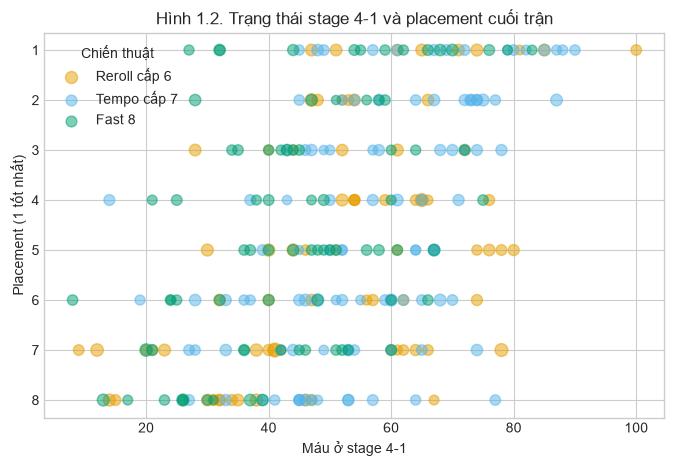

In [5]:
mau = tran_tft.sample(260, random_state=20)

fig, ax = plt.subplots(figsize=(8, 5))
for chien_thuat in CHIEN_THUAT:
    d = mau[mau["chien_thuat"] == chien_thuat]
    ax.scatter(
        d["mau_4_1"],
        d["placement"],
        s=10 + 1.4 * d["gia_tri_doi_hinh"],
        alpha=0.50,
        color=MAU_CHIEN_THUAT[chien_thuat],
        label=chien_thuat,
    )

ax.invert_yaxis()
ax.set(
    title="Hình 1.2. Trạng thái stage 4-1 và placement cuối trận",
    xlabel="Máu ở stage 4-1",
    ylabel="Placement (1 tốt nhất)",
    yticks=range(1, 9),
)
ax.legend(title="Chiến thuật")
plt.show()


Phân tích Hình 1.2:

- **Dữ liệu:** 260 hàng được lấy từ `tran_tft`; một hàng là một người chơi trong một trận.
- **Ánh xạ:** x = máu ở 4-1, y = placement, màu = chiến thuật, kích thước = giá trị đội hình.
- **Hình học:** điểm.
- **Nhóm:** mỗi chiến thuật tạo thành một lớp màu.

Kích thước điểm lớn không có nghĩa là “quan trọng hơn”; nó chỉ đang mã hóa một biến khác. Một biểu đồ chứa quá nhiều ánh xạ cũng có thể khó đọc.

#### Cùng biến, dạng hình học khác


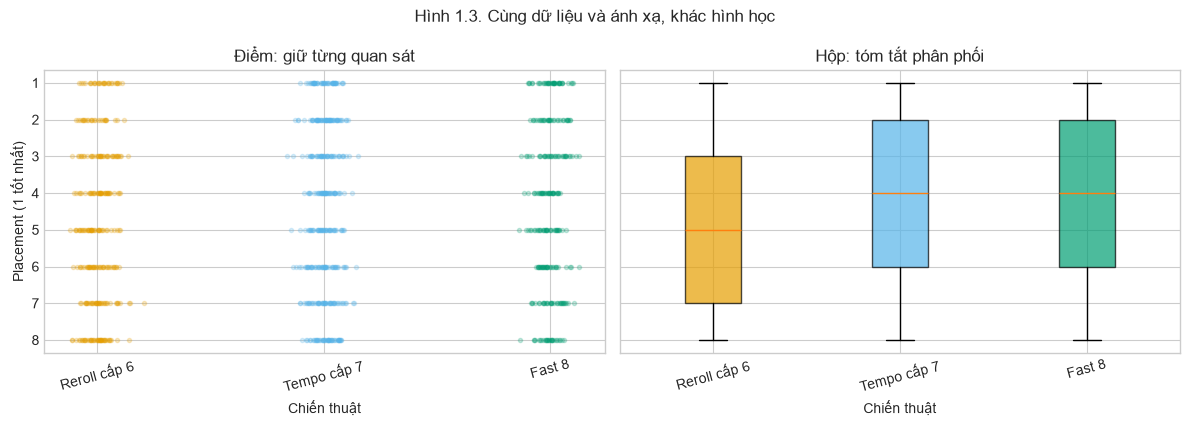

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3), sharey=True)

for j, chien_thuat in enumerate(CHIEN_THUAT):
    y = tran_tft.loc[tran_tft["chien_thuat"] == chien_thuat, "placement"].to_numpy()
    x = rng.normal(j + 1, 0.055, size=len(y))
    axes[0].scatter(x, y, s=9, alpha=0.22, color=MAU_CHIEN_THUAT[chien_thuat])

axes[0].set(
    title="Điểm: giữ từng quan sát",
    xlabel="Chiến thuật",
    ylabel="Placement (1 tốt nhất)",
    xticks=[1, 2, 3],
    xticklabels=CHIEN_THUAT,
)
axes[0].tick_params(axis="x", rotation=15)

du_lieu_hop = [
    tran_tft.loc[tran_tft["chien_thuat"] == c, "placement"] for c in CHIEN_THUAT
]
bp = axes[1].boxplot(du_lieu_hop, patch_artist=True)
axes[1].set_xticks(range(1, len(CHIEN_THUAT) + 1))
axes[1].set_xticklabels(CHIEN_THUAT)
for patch, c in zip(bp["boxes"], [MAU_CHIEN_THUAT[x] for x in CHIEN_THUAT]):
    patch.set_facecolor(c)
    patch.set_alpha(0.70)
axes[1].set(title="Hộp: tóm tắt phân phối", xlabel="Chiến thuật")
axes[1].tick_params(axis="x", rotation=15)

for ax in axes:
    ax.set_yticks(range(1, 9))
axes[0].invert_yaxis()

plt.suptitle("Hình 1.3. Cùng dữ liệu và ánh xạ, khác hình học")
plt.tight_layout()
plt.show()


Biểu đồ điểm cho thấy từng trận và mức độ chồng lấp. Boxplot nén dữ liệu thành trung vị, tứ phân vị và các điểm xa. Không có dạng hình học “tốt nhất” cho mọi câu hỏi.

#### Facet: điều kiện hóa bằng hình


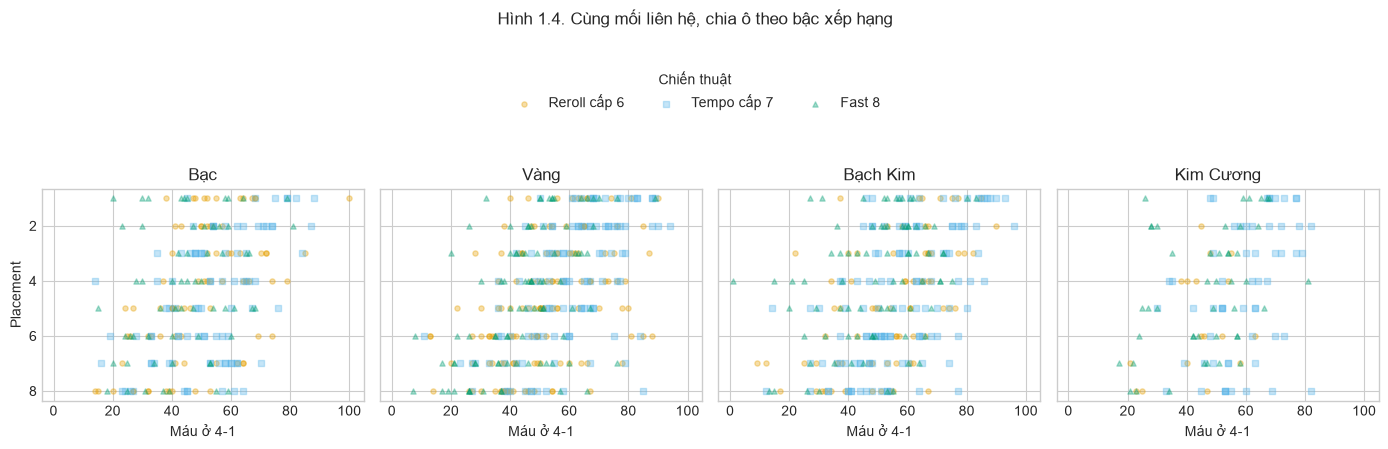

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.8), sharex=True, sharey=True)
KY_HIEU = {"Reroll cấp 6": "o", "Tempo cấp 7": "s", "Fast 8": "^"}

for ax, bac in zip(axes, BAC):
    d = tran_tft[tran_tft["bac_xep_hang"] == bac]
    for chien_thuat in CHIEN_THUAT:
        g = d[d["chien_thuat"] == chien_thuat]
        ax.scatter(
            g["mau_4_1"],
            g["placement"],
            s=14,
            alpha=0.34,
            color=MAU_CHIEN_THUAT[chien_thuat],
            marker=KY_HIEU[chien_thuat],
            label=chien_thuat,
        )
    ax.set_title(bac)
    ax.set_xlabel("Máu ở 4-1")

axes[0].set_ylabel("Placement")
axes[0].invert_yaxis()
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title="Chiến thuật",
    ncol=3,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.04),
)
plt.suptitle(
    "Hình 1.4. Cùng mối liên hệ, chia ô theo bậc xếp hạng",
    y=1.17,
)
plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.show()


> **W03-TFT-EX01 — Phân tích cú pháp Hình 1.4.**
>
> - Đơn vị quan sát là gì?
> - x, y, màu và facet lần lượt dùng biến nào?
> - Chia facet giúp nhìn thấy điều gì mà hình gộp có thể che mất?

<details><summary>Đáp án</summary>

- Mỗi điểm là một người chơi trong một trận.
- x = `mau_4_1`; y = `placement`; màu = `chien_thuat`; facet = `bac_xep_hang`.
- Ta có thể kiểm tra xem mối liên hệ và mức độ phân tán có giống nhau giữa các bậc không, thay vì để cơ cấu bậc chi phối hình gộp.

</details>

### 1.3 Ánh xạ hay thiết lập?

- **Thiết lập:** tất cả điểm cùng một màu do người vẽ chọn.
- **Ánh xạ:** màu thay đổi theo giá trị của một biến.


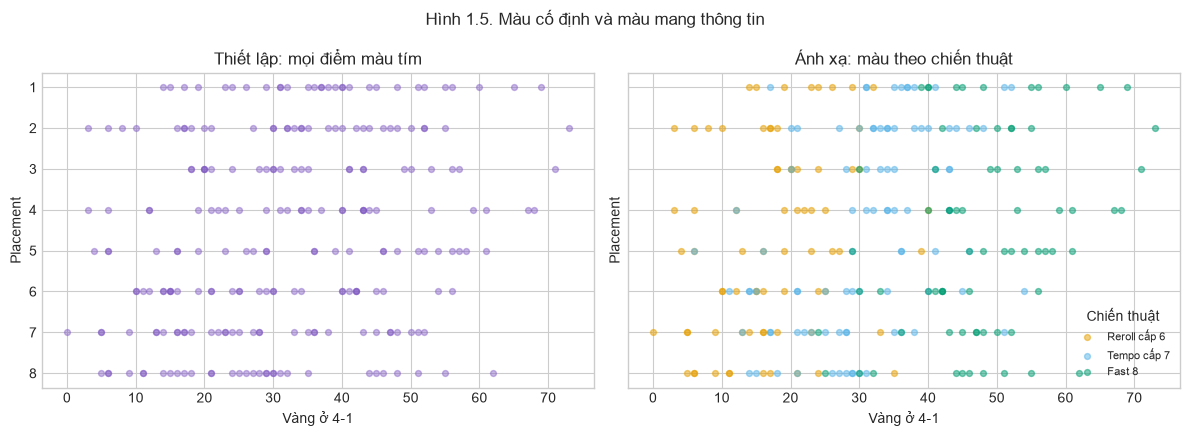

In [8]:
mau_nho = tran_tft.sample(240, random_state=3)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), sharex=True, sharey=True)

axes[0].scatter(mau_nho["vang_4_1"], mau_nho["placement"],
                color="#7E57C2", alpha=0.42, s=18)
axes[0].set_title("Thiết lập: mọi điểm màu tím")

for chien_thuat in CHIEN_THUAT:
    d = mau_nho[mau_nho["chien_thuat"] == chien_thuat]
    axes[1].scatter(d["vang_4_1"], d["placement"], alpha=0.50, s=18,
                    color=MAU_CHIEN_THUAT[chien_thuat], label=chien_thuat)
axes[1].set_title("Ánh xạ: màu theo chiến thuật")
axes[1].legend(title="Chiến thuật", fontsize=8)

for ax in axes:
    ax.set(xlabel="Vàng ở 4-1", ylabel="Placement", yticks=range(1, 9))
axes[0].invert_yaxis()

plt.suptitle("Hình 1.5. Màu cố định và màu mang thông tin")
plt.tight_layout()
plt.show()


> **W03-TFT-Q02.** Ở hình bên phải, nếu đổi bảng màu thì dữ liệu có đổi không? Nếu xóa chú giải, người đọc mất thông tin gì?

<details><summary>Đáp án</summary>

Dữ liệu không đổi khi đổi bảng màu, nhưng khả năng đọc và tiếp cận có thể đổi. Nếu xóa chú giải, người đọc không còn biết màu nào ứng với chiến thuật nào; ánh xạ vẫn tồn tại trong code nhưng không được giao tiếp đầy đủ.

</details>

### 1.4 Dạng hình học không chỉ là phong cách

Đường nối nói rằng các quan sát có **thứ tự** và ta quan tâm đến chuyển động từ quan sát này sang quan sát tiếp theo. Nối các người chơi không liên quan chỉ vì họ đang nằm cạnh nhau trong bảng sẽ tạo ra một câu chuyện giả.


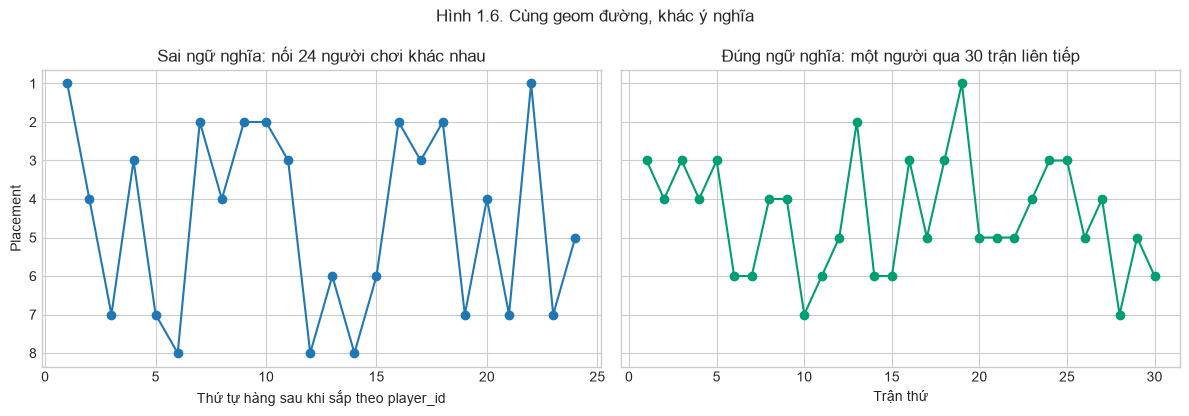

In [9]:
ngang = tran_tft.sample(24, random_state=12).sort_values("player_id")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
axes[0].plot(np.arange(1, len(ngang) + 1), ngang["placement"], marker="o")
axes[0].set(
    title="Sai ngữ nghĩa: nối 24 người chơi khác nhau",
    xlabel="Thứ tự hàng sau khi sắp theo player_id",
    ylabel="Placement",
)

axes[1].plot(lich_su["tran_thu"], lich_su["placement"], marker="o", color="#009E73")
axes[1].set(
    title="Đúng ngữ nghĩa: một người qua 30 trận liên tiếp",
    xlabel="Trận thứ",
)

for ax in axes:
    ax.set_yticks(range(1, 9))
axes[0].invert_yaxis()

plt.suptitle("Hình 1.6. Cùng geom đường, khác ý nghĩa")
plt.tight_layout()
plt.show()


<details><summary>Vì sao hình bên trái gây hiểu lầm?</summary>

Mỗi điểm thuộc một người chơi–trận khác nhau. Đường nối ngầm kể rằng có một quá trình chuyển từ điểm trước sang điểm sau, nhưng quá trình ấy không tồn tại. Ở hình bên phải, `tran_thu` là thời gian có thứ tự của cùng một người nên đường nối có ý nghĩa.

</details>


---
## Phần 2. Một người chơi TFT qua thời gian

### 2.1 Điểm hay đường?

`lich_su` chứa 30 trận liên tiếp của cùng một người chơi giả định. Placement dao động mạnh giữa từng trận; đường trung bình trượt 5 trận giúp nhìn xu hướng mà không xóa dữ liệu gốc.


In [10]:
lich_su.head(10)


,tran_thu,placement,chien_thuat,top4,placement_tb_5_tran
0,1,3,Fast 8,True,3.000
1,2,4,Tempo cấp 7,True,3.500
2,3,3,Fast 8,True,3.333
3,4,4,Reroll cấp 6,True,3.500
4,5,3,Tempo cấp 7,True,3.400
5,6,6,Reroll cấp 6,False,4.000
6,7,6,Fast 8,False,4.400
7,8,4,Tempo cấp 7,True,4.600
8,9,4,Tempo cấp 7,True,4.600
9,10,7,Tempo cấp 7,False,5.400


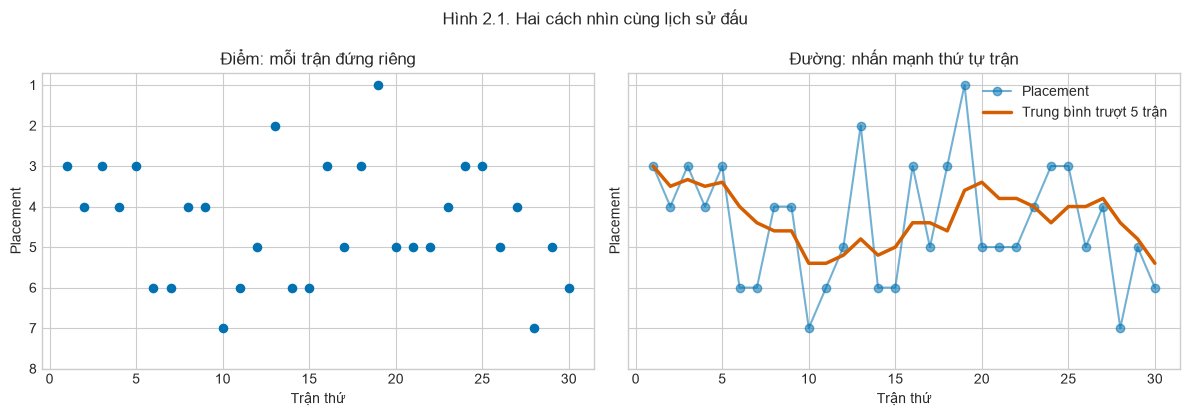

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)

axes[0].scatter(lich_su["tran_thu"], lich_su["placement"],
                color="#0072B2", s=35)
axes[0].set_title("Điểm: mỗi trận đứng riêng")

axes[1].plot(lich_su["tran_thu"], lich_su["placement"],
             color="#0072B2", marker="o", alpha=0.55, label="Placement")
axes[1].plot(lich_su["tran_thu"], lich_su["placement_tb_5_tran"],
             color="#D55E00", linewidth=2.5, label="Trung bình trượt 5 trận")
axes[1].legend()
axes[1].set_title("Đường: nhấn mạnh thứ tự trận")

for ax in axes:
    ax.set(xlabel="Trận thứ", ylabel="Placement", yticks=range(1, 9))
axes[0].invert_yaxis()

plt.suptitle("Hình 2.1. Hai cách nhìn cùng lịch sử đấu")
plt.tight_layout()
plt.show()


> **W03-TFT-Q03.**
>
> 1. Đường trung bình trượt có phải là dữ liệu của một trận thật không?
> 2. Vì sao không nên chỉ vẽ đường trung bình trượt rồi xóa các điểm?
> 3. Nếu xáo trộn thứ tự trận, đường nào bị mất ý nghĩa?

<details><summary>Đáp án</summary>

1. Không. Nó là một thống kê tính từ cửa sổ gồm nhiều trận.
2. Chỉ vẽ đường mượt sẽ che mất độ biến động trận–trận và có thể làm người đọc tưởng quá trình ổn định hơn thực tế.
3. Cả đường nối placement lẫn trung bình trượt đều dựa vào thứ tự thời gian, nên đều mất ý nghĩa khi xáo trộn.

</details>

### 2.2 Giao tiếp bằng nhãn và chú thích


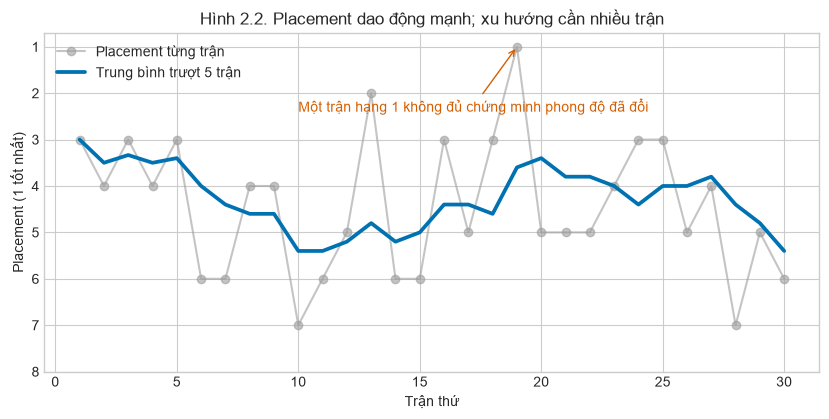

In [12]:
fig, ax = plt.subplots(figsize=(10, 4.4))
ax.plot(lich_su["tran_thu"], lich_su["placement"], color="#9E9E9E",
        marker="o", alpha=0.60, label="Placement từng trận")
ax.plot(lich_su["tran_thu"], lich_su["placement_tb_5_tran"],
        color="#0072B2", linewidth=2.7, label="Trung bình trượt 5 trận")

placement_tot = int(lich_su["placement"].min())
tran_tot = int(lich_su.loc[lich_su["placement"] == placement_tot, "tran_thu"].iloc[0])
ax.annotate(
    f"Một trận hạng {placement_tot} không đủ chứng minh phong độ đã đổi",
    xy=(tran_tot, placement_tot),
    xytext=(max(1, tran_tot - 9), min(7.5, placement_tot + 1.4)),
    arrowprops={"arrowstyle": "->", "color": "#D55E00"},
    color="#D55E00",
)
ax.set(
    title="Hình 2.2. Placement dao động mạnh; xu hướng cần nhiều trận",
    xlabel="Trận thứ",
    ylabel="Placement (1 tốt nhất)",
    yticks=range(1, 9),
)
ax.invert_yaxis()
ax.legend()
plt.show()


Tiêu đề tốt nói điều người đọc cần thấy, không chỉ nói “Biểu đồ đường”. Chú thích phải hỗ trợ kết luận vừa đủ: một trận có placement tốt là một điểm dữ liệu, không phải bằng chứng chắc chắn rằng kỹ năng hay chiến thuật đã thay đổi.


### 2.3 Thay đổi và quan sát

Đổi `CUA_SO` lần lượt thành 3 và 10 rồi chạy lại ô dưới. Cửa sổ lớn hơn làm đường mượt hơn, nhưng đánh đổi khả năng phản ứng nhanh với thay đổi gần đây.


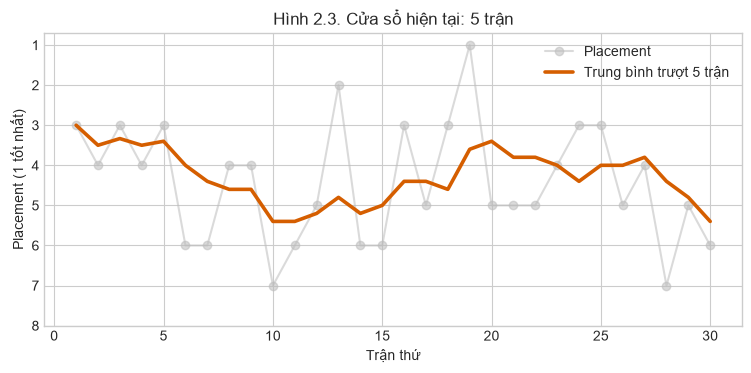

In [13]:
CUA_SO = 5  # Thử 3 và 10
duong_muot = lich_su["placement"].rolling(CUA_SO, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.plot(lich_su["tran_thu"], lich_su["placement"],
        color="#BDBDBD", marker="o", alpha=0.55, label="Placement")
ax.plot(lich_su["tran_thu"], duong_muot,
        color="#D55E00", linewidth=2.6,
        label=f"Trung bình trượt {CUA_SO} trận")
ax.set(
    title=f"Hình 2.3. Cửa sổ hiện tại: {CUA_SO} trận",
    xlabel="Trận thứ",
    ylabel="Placement (1 tốt nhất)",
    yticks=range(1, 9),
)
ax.invert_yaxis()
ax.legend()
plt.show()


> **W03-TFT-EX-THỬ.** Khi tăng cửa sổ từ 3 lên 10, đặc điểm nào của dữ liệu không đổi? Đặc điểm nào của đường tóm tắt đổi? Có nên chọn cửa sổ sau khi đã nhìn thấy đường nào kể câu chuyện “đẹp nhất” không?


---
## Phần 3. Python phản chiếu ngữ pháp đồ họa

### 3.1 Từ câu hỏi tới code

Câu hỏi: *Trong các trận bậc Vàng, máu ở stage 4-1 liên hệ với placement thế nào, và ba chiến thuật có khác nhau không?*

Ta có thể đọc code thành bốn bước: chọn dữ liệu, chọn ánh xạ, chọn hình học, thêm nhãn.


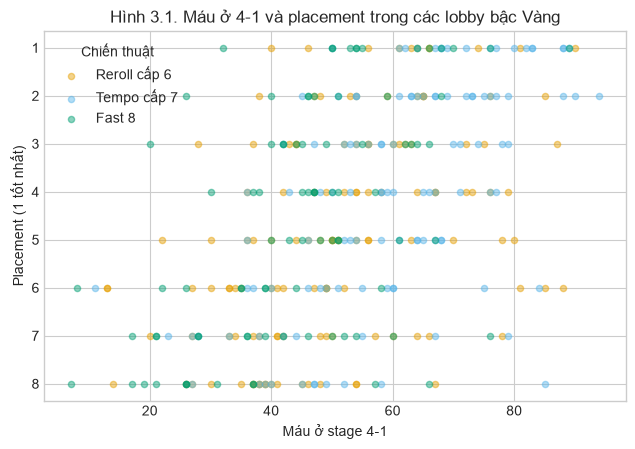

In [14]:
# Bước 1 — Data: chỉ giữ các trận bậc Vàng.
du_lieu_hinh = tran_tft.query("bac_xep_hang == 'Vàng'").copy()

# Bước 2 và 3 — Mapping + geometry: x, y, màu và điểm.
fig, ax = plt.subplots(figsize=(7.5, 4.8))
for chien_thuat in CHIEN_THUAT:
    d = du_lieu_hinh[du_lieu_hinh["chien_thuat"] == chien_thuat]
    ax.scatter(d["mau_4_1"], d["placement"], s=20, alpha=0.45,
               color=MAU_CHIEN_THUAT[chien_thuat], label=chien_thuat)

# Bước 4 — Giao tiếp.
ax.set(
    title="Hình 3.1. Máu ở 4-1 và placement trong các lobby bậc Vàng",
    xlabel="Máu ở stage 4-1",
    ylabel="Placement (1 tốt nhất)",
    yticks=range(1, 9),
)
ax.invert_yaxis()
ax.legend(title="Chiến thuật")
plt.show()


> **W03-TFT-PY01 — Đọc code, chưa cần chạy lại.**
>
> 1. Dòng nào quyết định quần thể con đang được xem?
> 2. Dòng nào ánh xạ chiến thuật vào màu?
> 3. Nếu đổi `mau_4_1` thành `vang_4_1`, thành phần nào của ngữ pháp đã đổi?
> 4. Nếu đổi scatter thành boxplot placement theo chiến thuật, thành phần nào đổi?

<details><summary>Đáp án</summary>

1. `.query("bac_xep_hang == 'Vàng'")`.
2. Vòng lặp chia theo `chien_thuat` và đối số `color=MAU_CHIEN_THUAT[chien_thuat]`.
3. Ánh xạ x đổi.
4. Dạng hình học đổi; boxplot còn đòi hỏi ánh xạ x theo nhóm thay vì x là một biến số liên tục.

</details>

### 3.2 Chỉ đổi một thành phần

Ô dưới giữ nguyên dữ liệu bậc Vàng nhưng thay câu hỏi: thay vì liên hệ giữa hai biến số, ta tóm tắt phân phối placement theo loại lõi.


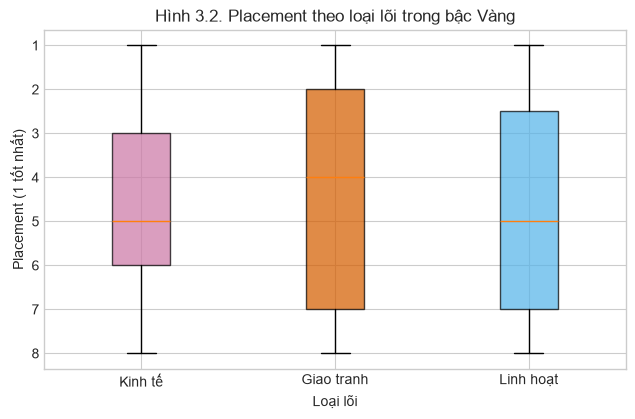

In [15]:
du_lieu_loi = [
    du_lieu_hinh.loc[du_lieu_hinh["loai_loi"] == loai, "placement"] for loai in LOI
]

fig, ax = plt.subplots(figsize=(7.5, 4.4))
bp = ax.boxplot(du_lieu_loi, patch_artist=True)
ax.set_xticks(range(1, len(LOI) + 1))
ax.set_xticklabels(LOI)
for patch, color in zip(bp["boxes"], ["#CC79A7", "#D55E00", "#56B4E9"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.72)
ax.set(
    title="Hình 3.2. Placement theo loại lõi trong bậc Vàng",
    xlabel="Loại lõi",
    ylabel="Placement (1 tốt nhất)",
    yticks=range(1, 9),
)
ax.invert_yaxis()
plt.show()


Không phải cứ thêm màu và kích thước là biểu đồ tốt hơn. Hình 3.2 chỉ dùng những thành phần cần thiết cho câu hỏi về phân phối placement giữa ba nhóm lõi.


### 3.3 Số điểm có thể ít hơn số hàng

Telemetry `so_lan_scout` được mô phỏng là thiếu ở khoảng 4% số hàng. Muốn vẽ biến này, ta phải xác định những hàng đủ thông tin. Việc bỏ hàng thiếu là một quyết định phân tích, không phải thao tác vô nghĩa.


Số hàng ban đầu: 960
Số hàng có ghi nhận scout: 922
Số hàng bị thiếu: 38


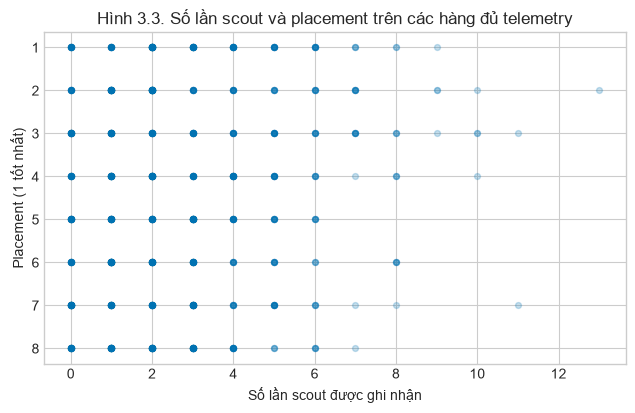

In [16]:
du_scout = tran_tft.dropna(subset=["so_lan_scout"])
print("Số hàng ban đầu:", len(tran_tft))
print("Số hàng có ghi nhận scout:", len(du_scout))
print("Số hàng bị thiếu:", tran_tft["so_lan_scout"].isna().sum())

fig, ax = plt.subplots(figsize=(7.5, 4.3))
ax.scatter(
    du_scout["so_lan_scout"],
    du_scout["placement"],
    alpha=0.22,
    s=18,
    color="#0072B2",
)
ax.set(
    title="Hình 3.3. Số lần scout và placement trên các hàng đủ telemetry",
    xlabel="Số lần scout được ghi nhận",
    ylabel="Placement (1 tốt nhất)",
    yticks=range(1, 9),
)
ax.invert_yaxis()
plt.show()


> **W03-TFT-PY02B.** Vì sao không được mặc nhiên nói các hàng còn lại là “mẫu ngẫu nhiên” của toàn bộ bảng? Nếu telemetry thường hỏng ở các trận ngắn hoặc khi người chơi thoát sớm, biểu đồ có thể lệch theo hướng nào?

<details><summary>Đáp án</summary>

`dropna()` chỉ loại hàng; nó không chứng minh cơ chế thiếu là ngẫu nhiên. Nếu trận kết thúc sớm hoặc người chơi thoát sớm dễ bị thiếu telemetry, dữ liệu còn lại sẽ đại diện quá nhiều cho các trận kéo dài hoặc người chơi trụ lâu. Khi ấy quan hệ quan sát được có thể bị selection bias.

</details>


---
## Phần 4. Điều kiện hóa: lọc đúng phần dữ liệu cần xem

### 4.1 Điều kiện hóa trong notebook này nghĩa là gì?

Điều kiện hóa nghĩa là chỉ xem các hàng thỏa một điều kiện, hoặc chia dữ liệu thành các nhóm rồi xem từng nhóm. Ví dụ:

- chỉ các trận bậc Kim Cương;
- chỉ chiến thuật Fast 8;
- các trận vừa Fast 8 **và** còn ít nhất 50 máu ở 4-1;
- so sánh riêng trong lobby nhanh và lobby chậm.


#### Chọn cột không phải lọc hàng

- `tran_tft[["mau_4_1", "placement"]]` giữ mọi hàng nhưng chỉ lấy hai cột.
- `tran_tft.query("mau_4_1 >= 50")` giữ mọi cột nhưng chỉ lấy các hàng thỏa điều kiện.

Hai thao tác thay đổi hai chiều khác nhau của bảng và trả lời các câu hỏi khác nhau.


In [17]:
kim_cuong = tran_tft.query("bac_xep_hang == 'Kim Cương'")
print("Số quan sát bậc Kim Cương:", len(kim_cuong))
kim_cuong[
    ["lobby_id", "chien_thuat", "mau_4_1", "vang_4_1", "placement", "top4"]
].head()


Số quan sát bậc Kim Cương: 120


,lobby_id,chien_thuat,mau_4_1,vang_4_1,placement,top4
24,L004,Fast 8,68,54,1,True
25,L004,Tempo cấp 7,72,44,2,True
26,L004,Fast 8,35,55,3,True
27,L004,Reroll cấp 6,43,21,4,True
28,L004,Tempo cấp 7,63,29,5,False


> **W03-TFT-PY02 — Đọc một phép lọc.**
>
> `tran_tft.query("bac_xep_hang == 'Kim Cương'")` giữ lại hàng nào? Nó có làm thay đổi số cột không? Nó có biến dữ liệu thành một bảng mỗi lobby không?

<details><summary>Đáp án</summary>

Phép lọc giữ các hàng có bậc Kim Cương, không tự đổi số cột và không đổi đơn vị quan sát. Mỗi hàng vẫn là một người chơi trong một trận.

</details>

### 4.2 Nhiều điều kiện: “và” hay “hoặc”


In [18]:
fast8_khoe = tran_tft.query(
    "chien_thuat == 'Fast 8' and mau_4_1 >= 50"
)

reroll_hoac_fast8 = tran_tft[
    tran_tft["chien_thuat"].isin(["Reroll cấp 6", "Fast 8"])
]

print("Fast 8 và còn ít nhất 50 máu:", len(fast8_khoe))
print("Reroll hoặc Fast 8:", len(reroll_hoac_fast8))
fast8_khoe.head()


Fast 8 và còn ít nhất 50 máu: 126
Reroll hoặc Fast 8: 573


,lobby_id,player_id,bac_xep_hang,nhip_lobby,chien_thuat,loai_loi,mau_4_1,vang_4_1,cap_4_1,so_lan_roll,so_tuong_3_sao,so_lan_scout,gia_tri_doi_hinh,placement,top4,win,sat_thuong_nguoi_choi,tong_sat_thuong
1,L001,P035,Bạc,Chậm,Fast 8,Kinh tế,56,37,8,0,0,1.000,28.000,2,True,False,87,41430
23,L003,P069,Vàng,Chậm,Fast 8,Linh hoạt,57,62,8,3,0,4.000,32.500,8,False,False,32,18073
24,L004,P221,Kim Cương,Nhanh,Fast 8,Giao tranh,68,54,9,4,0,3.000,41.200,1,True,True,106,30218
34,L005,P169,Bạch Kim,Nhanh,Fast 8,Giao tranh,60,20,7,13,0,8.000,29.100,3,True,False,81,28221
42,L006,P082,Vàng,Chậm,Fast 8,Linh hoạt,62,56,8,13,0,3.000,31.900,3,True,False,100,38898


- `and` yêu cầu **cả hai** điều kiện đúng.
- `or` chỉ cần **ít nhất một** điều kiện đúng.
- `.isin([...])` thường dễ đọc hơn một chuỗi dài các điều kiện “hoặc”.

Ngưỡng lọc phải xuất phát từ câu hỏi. Nếu thử 40, 45, 50, 55 rồi chỉ báo cáo ngưỡng cho kết quả đẹp nhất, ta đã dùng kết quả để tự chọn câu hỏi và dễ phóng đại bằng chứng.

> **W03-TFT-Q04.** Viết điều kiện cho: “các trận lobby nhanh, dùng Tempo cấp 7 hoặc Fast 8, và placement không quá 4”.

<details><summary>Một đáp án</summary>

```python
tran_tft[
    (tran_tft["nhip_lobby"] == "Nhanh")
    & (tran_tft["chien_thuat"].isin(["Tempo cấp 7", "Fast 8"]))
    & (tran_tft["placement"] <= 4)
]
```

</details>

### 4.3 Điều kiện là một biến logic


In [19]:
vi_du_logic = tran_tft.assign(
    con_50_mau_o_4_1=tran_tft["mau_4_1"] >= 50,
    ket_qua_top4=tran_tft["placement"] <= 4,
)

vi_du_logic[
    ["mau_4_1", "placement", "con_50_mau_o_4_1", "ket_qua_top4"]
].head(8)


,mau_4_1,placement,con_50_mau_o_4_1,ket_qua_top4
0,38,1,False,True
1,56,2,True,True
2,50,3,True,True
3,74,4,True,True
4,42,5,False,False
5,49,6,False,False
6,34,7,False,False
7,64,8,True,False


In [20]:
print("Tỉ lệ còn ít nhất 50 máu ở 4-1:",
      vi_du_logic["con_50_mau_o_4_1"].mean())
print("Tỉ lệ top 4:",
      vi_du_logic["ket_qua_top4"].mean())


Tỉ lệ còn ít nhất 50 máu ở 4-1: 0.5697916666666667
Tỉ lệ top 4: 0.5


Trong Python, `True` hoạt động như 1 và `False` như 0 khi lấy trung bình. Vì vậy trung bình của biến logic là một **tỉ lệ**.

Ở đây tỉ lệ top 4 toàn bảng bằng 0,5 theo thiết kế: mỗi lobby luôn có 4 trong 8 người thuộc top 4. Con số đúng nhưng chưa cho biết chiến thuật hoặc bậc nào khác nhau ra sao.


### 4.4 Khi thang đo che mất hình dạng

`tong_sat_thuong` có đuôi phải dài: một số trận kéo dài tạo tổng sát thương lớn hơn phần đông nhiều lần. Logarit không thay đổi thứ tự các giá trị dương, nhưng nén khoảng cách và giúp thấy phần thân phân phối rõ hơn.


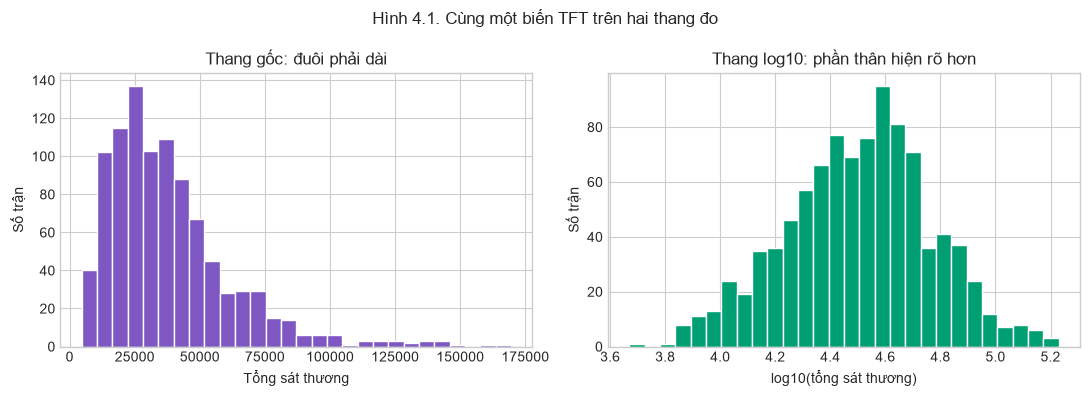

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.0))

axes[0].hist(tran_tft["tong_sat_thuong"], bins=28, color="#7E57C2", edgecolor="white")
axes[0].set(
    title="Thang gốc: đuôi phải dài",
    xlabel="Tổng sát thương",
    ylabel="Số trận",
)

axes[1].hist(np.log10(tran_tft["tong_sat_thuong"]), bins=28,
             color="#009E73", edgecolor="white")
axes[1].set(
    title="Thang log10: phần thân hiện rõ hơn",
    xlabel="log10(tổng sát thương)",
    ylabel="Số trận",
)

plt.suptitle("Hình 4.1. Cùng một biến TFT trên hai thang đo")
plt.tight_layout()
plt.show()


Log-transform không tự làm dữ liệu “tốt hơn” và không biến quan hệ thành nhân quả. Nó là một lựa chọn biểu diễn cần được ghi rõ trên trục.


---
## Phần 5. Pipeline và phép toán theo nhóm

### 5.1 Pipeline là một lập luận

Đọc chuỗi dưới đây như một câu:

> Lấy dữ liệu TFT → giữ lobby nhanh → tạo biến còn nhiều máu → nhóm theo chiến thuật → tính số trận, placement trung bình, tỉ lệ top 4 và tỉ lệ còn nhiều máu → sắp theo tỉ lệ top 4.


In [22]:
tom_tat_nhanh = (
    tran_tft
    .query("nhip_lobby == 'Nhanh'")
    .assign(con_nhieu_mau=lambda d: d["mau_4_1"] >= 50)
    .groupby("chien_thuat", observed=True)
    .agg(
        so_tran=("placement", "size"),
        placement_tb=("placement", "mean"),
        ti_le_top4=("top4", "mean"),
        ti_le_con_nhieu_mau=("con_nhieu_mau", "mean"),
    )
    .sort_values("ti_le_top4", ascending=False)
)

tom_tat_nhanh


,so_tran,placement_tb,ti_le_top4,ti_le_con_nhieu_mau
chien_thuat,,,,
Fast 8,167,4.078,0.581,0.431
Tempo cấp 7,222,4.482,0.486,0.631
Reroll cấp 6,75,5.493,0.360,0.427


> **W03-TFT-PY03.**
>
> 1. Nếu bỏ bước `.query(...)`, câu hỏi đổi thế nào?
> 2. Nếu nhóm theo `loai_loi` thay vì `chien_thuat`, đơn vị của mỗi hàng kết quả là gì?
> 3. Vì sao cần `observed=True` với biến phân loại trong ví dụ này?

<details><summary>Đáp án</summary>

1. Kết quả chuyển từ lobby nhanh sang toàn bộ lobby.
2. Mỗi hàng kết quả là một loại lõi.
3. Nó yêu cầu pandas chỉ trả các nhóm phân loại thực sự xuất hiện trong dữ liệu đang xét, tránh các mức rỗng không cần thiết.

</details>

### 5.2 Lọc hay nhóm?


In [23]:
print("(1) Lọc rồi tóm tắt — chỉ trả lời về Fast 8")
display(
    tran_tft
    .query("chien_thuat == 'Fast 8'")
    .agg(
        placement_tb=("placement", "mean"),
        ti_le_top4=("top4", "mean"),
    )
)

print("(2) Nhóm rồi tóm tắt — so sánh ba chiến thuật")
display(
    tran_tft
    .groupby("chien_thuat", observed=True)
    .agg(
        placement_tb=("placement", "mean"),
        ti_le_top4=("top4", "mean"),
    )
)


(1) Lọc rồi tóm tắt — chỉ trả lời về Fast 8


,placement,top4
placement_tb,4.303,NaN
ti_le_top4,NaN,0.533


(2) Nhóm rồi tóm tắt — so sánh ba chiến thuật


,placement_tb,ti_le_top4
chien_thuat,,
Reroll cấp 6,4.786,0.452
Tempo cấp 7,4.419,0.514
Fast 8,4.303,0.533


Lọc loại bỏ các hàng ngoài phạm vi câu hỏi. Nhóm giữ các hàng nhưng thay đổi cách phép tính tiếp theo được áp dụng. Hai thao tác không thay thế nhau.

#### Thứ tự thao tác có thể đổi câu hỏi

Nếu lọc `top4 == True` trước rồi mới lấy trung bình `top4`, mọi nhóm đều cho 100%. Đó không còn là câu hỏi “tỉ lệ top 4 của mỗi chiến thuật là bao nhiêu?” mà chỉ mô tả tập đã được định nghĩa là top 4.


In [24]:
so_sanh_thu_tu = pd.concat(
    {
        "Nhóm trước, tính tỉ lệ trên mọi trận": (
            tran_tft
            .groupby("chien_thuat", observed=True)["top4"]
            .mean()
        ),
        "Lọc top 4 trước, rồi lấy mean": (
            tran_tft
            .query("top4")
            .groupby("chien_thuat", observed=True)["top4"]
            .mean()
        ),
    },
    axis=1,
)
so_sanh_thu_tu


,"Nhóm trước, tính tỉ lệ trên mọi trận","Lọc top 4 trước, rồi lấy mean"
chien_thuat,,
Reroll cấp 6,0.452,1.000
Tempo cấp 7,0.514,1.000
Fast 8,0.533,1.000


> **W03-TFT-EX03.** Diễn giải bằng lời hai cột trên. Bước nào làm thay đổi mẫu số? Vì sao code vẫn chạy đúng nhưng câu trả lời thứ hai không còn hữu ích cho câu hỏi ban đầu?

### 5.3 Nhóm rồi tóm tắt


In [25]:
tom_tat_chien_thuat = (
    tran_tft
    .groupby("chien_thuat", observed=True)
    .agg(
        so_tran=("placement", "size"),
        placement_tb=("placement", "mean"),
        ti_le_top4=("top4", "mean"),
        ti_le_thang=("win", "mean"),
        mau_4_1_tb=("mau_4_1", "mean"),
        vang_4_1_tb=("vang_4_1", "mean"),
    )
    .reset_index()
)

tom_tat_chien_thuat


,chien_thuat,so_tran,placement_tb,ti_le_top4,ti_le_thang,mau_4_1_tb,vang_4_1_tb
0,Reroll cấp 6,299,4.786,0.452,0.100,50.913,17.301
1,Tempo cấp 7,387,4.419,0.514,0.127,57.367,30.289
2,Fast 8,274,4.303,0.533,0.150,46.212,47.876


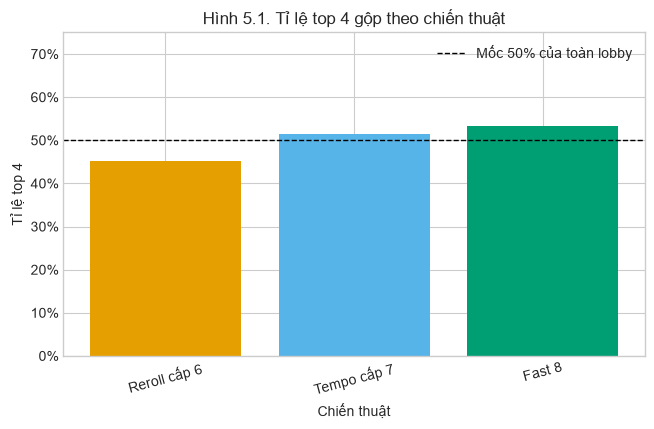

In [26]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.bar(
    tom_tat_chien_thuat["chien_thuat"].astype(str),
    tom_tat_chien_thuat["ti_le_top4"],
    color=[MAU_CHIEN_THUAT[x] for x in CHIEN_THUAT],
)
ax.axhline(0.5, color="black", linestyle="--", linewidth=1,
           label="Mốc 50% của toàn lobby")
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set(
    title="Hình 5.1. Tỉ lệ top 4 gộp theo chiến thuật",
    xlabel="Chiến thuật",
    ylabel="Tỉ lệ top 4",
    ylim=(0, 0.75),
)
ax.tick_params(axis="x", rotation=15)
ax.legend()
plt.show()


> **W03-TFT-EX02.** Hãy nhóm đồng thời theo `nhip_lobby` và `chien_thuat`, rồi tính số trận và tỉ lệ top 4. Vì sao bảng này trả lời câu hỏi khác Hình 5.1?


In [27]:
top4_theo_nhip = (
    tran_tft
    .groupby(["nhip_lobby", "chien_thuat"], observed=True)
    .agg(
        so_tran=("top4", "size"),
        ti_le_top4=("top4", "mean"),
    )
    .reset_index()
)

top4_theo_nhip


,nhip_lobby,chien_thuat,so_tran,ti_le_top4
0,Chậm,Reroll cấp 6,224,0.482
1,Chậm,Tempo cấp 7,165,0.552
2,Chậm,Fast 8,107,0.458
3,Nhanh,Reroll cấp 6,75,0.360
4,Nhanh,Tempo cấp 7,222,0.486
5,Nhanh,Fast 8,167,0.581


<details><summary>Đáp án</summary>

Hình 5.1 là phân phối **biên** theo chiến thuật: mọi nhịp lobby bị gộp lại. Bảng mới là tỉ lệ **có điều kiện** theo từng kết hợp nhịp lobby–chiến thuật. Nó cho phép kiểm tra xem kết luận gộp có giữ nguyên trong từng bối cảnh hay không.

</details>

### 5.4 Từ tỉ lệ có điều kiện tới nghịch lý Simpson

Xét một giải đấu TFT giả định. “Thành công” nghĩa là top 4. Hai chiến thuật được dùng với cơ cấu lobby rất khác nhau:

| Nhịp lobby | Reroll: top 4 / tổng | Fast 8: top 4 / tổng |
|---|---:|---:|
| Chậm | 81 / 90 | 19 / 20 |
| Nhanh | 1 / 10 | 16 / 80 |

Hãy tính tỉ lệ trong từng nhịp lobby và tỉ lệ gộp trước khi chạy code.


In [28]:
simpson_tft = pd.DataFrame(
    {
        "nhip_lobby": ["Chậm", "Nhanh", "Chậm", "Nhanh"],
        "chien_thuat": ["Reroll", "Reroll", "Fast 8", "Fast 8"],
        "top4": [81, 1, 19, 16],
        "tong": [90, 10, 20, 80],
    }
)
simpson_tft["ti_le_top4"] = simpson_tft["top4"] / simpson_tft["tong"]

theo_nhip = simpson_tft.pivot(
    index="nhip_lobby", columns="chien_thuat", values="ti_le_top4"
).loc[["Chậm", "Nhanh"]]

gop = simpson_tft.groupby("chien_thuat")[["top4", "tong"]].sum()
gop["ti_le_top4"] = gop["top4"] / gop["tong"]

print("Tỉ lệ trong từng nhịp lobby")
display(theo_nhip)
print("Tỉ lệ gộp")
display(gop)


Tỉ lệ trong từng nhịp lobby


chien_thuat,Fast 8,Reroll
nhip_lobby,,
Chậm,0.950,0.900
Nhanh,0.200,0.100


Tỉ lệ gộp


,top4,tong,ti_le_top4
chien_thuat,,,
Fast 8,35,100,0.350
Reroll,82,100,0.820


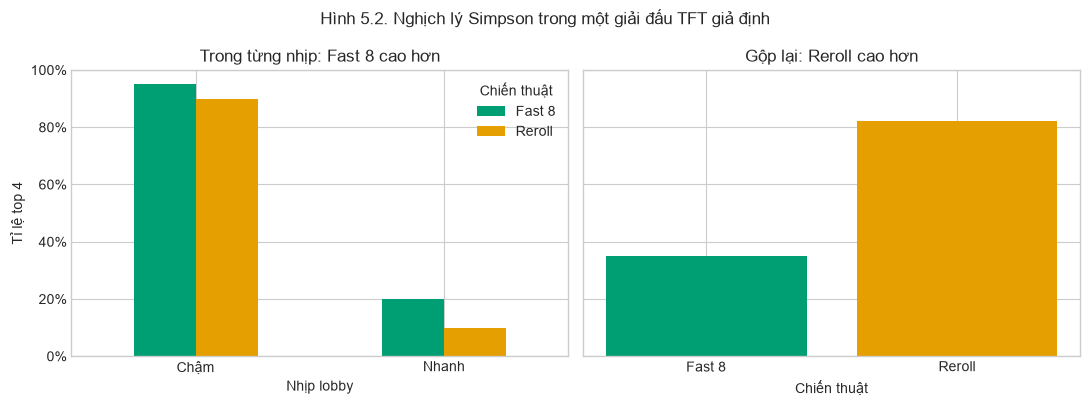

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.1), sharey=True)

theo_nhip.plot(kind="bar", ax=axes[0], rot=0, color=["#009E73", "#E69F00"])
axes[0].set(
    title="Trong từng nhịp: Fast 8 cao hơn",
    xlabel="Nhịp lobby",
    ylabel="Tỉ lệ top 4",
)
axes[0].legend(title="Chiến thuật")

axes[1].bar(gop.index, gop["ti_le_top4"], color=["#009E73", "#E69F00"])
axes[1].set(title="Gộp lại: Reroll cao hơn", xlabel="Chiến thuật")

for ax in axes:
    ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.set_ylim(0, 1)

plt.suptitle("Hình 5.2. Nghịch lý Simpson trong một giải đấu TFT giả định")
plt.tight_layout()
plt.show()


<details><summary>Giải thích</summary>

- Lobby chậm: Reroll 90%, Fast 8 95%.
- Lobby nhanh: Reroll 10%, Fast 8 20%.
- Trong **cả hai nhóm**, Fast 8 có tỉ lệ top 4 cao hơn.
- Khi gộp: Reroll 82%, Fast 8 35%.

Sự đảo chiều đến từ trọng số:

- 90% lượt Reroll nằm trong lobby chậm, nơi cả hai chiến thuật đều dễ top 4 hơn.
- 80% lượt Fast 8 nằm trong lobby nhanh, nơi cả hai chiến thuật đều khó top 4 hơn.

Do đó số gộp không chỉ phản ánh hiệu quả chiến thuật; nó còn phản ánh **chiến thuật được sử dụng trong loại lobby nào**. Không biết cơ chế chọn chiến thuật và phân bổ lobby, ta không được kết luận Fast 8 hay Reroll *gây ra* kết quả tốt hơn.

</details>

### 5.5 Cùng số liệu, khác ấn tượng

Số đếm và tỉ lệ trả lời hai câu hỏi khác nhau. Ô dưới so sánh số lượt top 4 với tỉ lệ top 4 theo loại lõi.


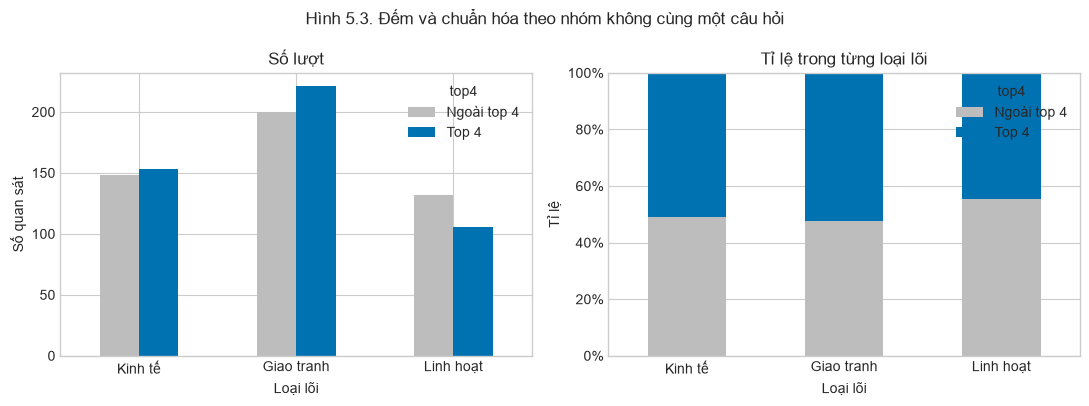

In [30]:
bang_loi = pd.crosstab(tran_tft["loai_loi"], tran_tft["top4"]).reindex(LOI)
ti_le_loi = pd.crosstab(
    tran_tft["loai_loi"], tran_tft["top4"], normalize="index"
).reindex(LOI)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.1))
bang_loi.rename(columns={False: "Ngoài top 4", True: "Top 4"}).plot(
    kind="bar", ax=axes[0], rot=0, color=["#BDBDBD", "#0072B2"]
)
axes[0].set(title="Số lượt", xlabel="Loại lõi", ylabel="Số quan sát")

ti_le_loi.rename(columns={False: "Ngoài top 4", True: "Top 4"}).plot(
    kind="bar", stacked=True, ax=axes[1], rot=0, color=["#BDBDBD", "#0072B2"]
)
axes[1].set(title="Tỉ lệ trong từng loại lõi", xlabel="Loại lõi", ylabel="Tỉ lệ")
axes[1].yaxis.set_major_formatter(PercentFormatter(1))
axes[1].set_ylim(0, 1)

plt.suptitle("Hình 5.3. Đếm và chuẩn hóa theo nhóm không cùng một câu hỏi")
plt.tight_layout()
plt.show()


Biểu đồ số đếm chịu ảnh hưởng trực tiếp bởi số lần mỗi loại lõi xuất hiện. Biểu đồ tỉ lệ chuẩn hóa từng nhóm về 100%, phù hợp hơn nếu câu hỏi là “trong mỗi loại lõi, bao nhiêu phần trăm trận vào top 4?”.


### 5.6 Trục bị cắt có thể phóng đại khác biệt

Hai biểu đồ sau dùng đúng cùng ba tỉ lệ. Hình bên phải cắt trục gần các giá trị quan sát, khiến một chênh lệch vừa phải trông rất lớn.


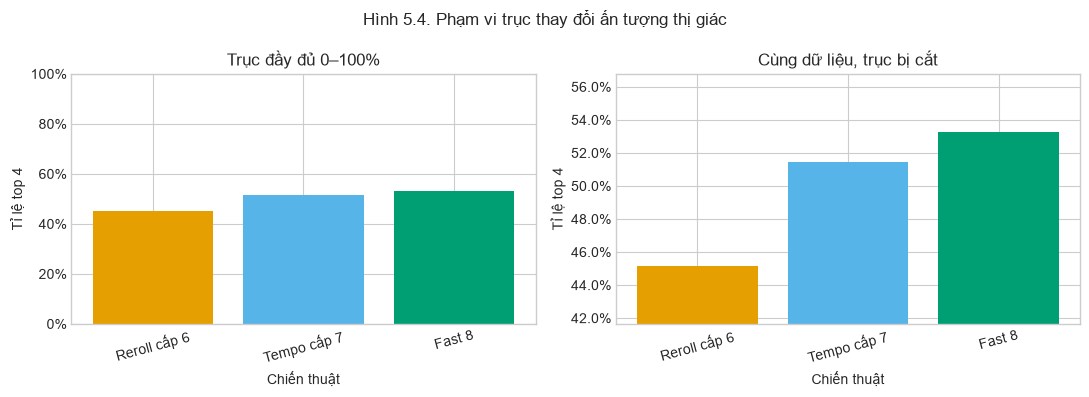

In [31]:
rates = (
    tom_tat_chien_thuat
    .set_index("chien_thuat")["ti_le_top4"]
    .reindex(CHIEN_THUAT)
)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.0))

for ax in axes:
    ax.bar(
        rates.index.astype(str),
        rates.values,
        color=[MAU_CHIEN_THUAT[x] for x in CHIEN_THUAT],
    )
    ax.tick_params(axis="x", rotation=15)
    ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.set_xlabel("Chiến thuật")

axes[0].set(title="Trục đầy đủ 0–100%", ylabel="Tỉ lệ top 4", ylim=(0, 1))
lo = max(0, rates.min() - 0.035)
hi = min(1, rates.max() + 0.035)
axes[1].set(title="Cùng dữ liệu, trục bị cắt", ylabel="Tỉ lệ top 4", ylim=(lo, hi))

plt.suptitle("Hình 5.4. Phạm vi trục thay đổi ấn tượng thị giác")
plt.tight_layout()
plt.show()


Khi chiều dài cột mã hóa độ lớn, cho trục bắt đầu từ 0 thường là lựa chọn trung thực hơn. Nếu cần nhấn mạnh chênh lệch nhỏ, point plot kèm khoảng tin cậy và nhãn số thường phù hợp hơn việc cắt chân cột.


---
## Phần 6. Thử thách tổng hợp

### 6.1 Một tỉ lệ đúng nhưng kết luận còn yếu

> **W03-TFT-CH01.** Một người phân tích thấy các trận còn ít nhất 50 máu ở stage 4-1 có tỉ lệ top 4 cao hơn. Bạn ấy kết luận:
>
> “Giữ được 50 máu ở 4-1 sẽ làm người chơi top 4.”
>
> 1. Hãy tính tỉ lệ top 4 cho hai nhóm dưới/trên 50 máu.
> 2. Điều kiện hóa thêm theo bậc xếp hạng.
> 3. Giải thích vì sao kết quả vẫn chưa đủ cho một khẳng định nhân quả.


In [32]:
phan_tich_mau = (
    tran_tft
    .assign(nhom_mau=np.where(tran_tft["mau_4_1"] >= 50, "Ít nhất 50", "Dưới 50"))
    .groupby("nhom_mau", observed=True)
    .agg(
        so_tran=("top4", "size"),
        ti_le_top4=("top4", "mean"),
        placement_tb=("placement", "mean"),
    )
    .sort_index()
)
phan_tich_mau


,so_tran,ti_le_top4,placement_tb
nhom_mau,,,
Dưới 50,413,0.305,5.494
Ít nhất 50,547,0.647,3.750


In [33]:
phan_tich_mau_theo_bac = (
    tran_tft
    .assign(nhom_mau=np.where(tran_tft["mau_4_1"] >= 50, "Ít nhất 50", "Dưới 50"))
    .groupby(["bac_xep_hang", "nhom_mau"], observed=True)
    .agg(
        so_tran=("top4", "size"),
        ti_le_top4=("top4", "mean"),
    )
    .reset_index()
)
phan_tich_mau_theo_bac


,bac_xep_hang,nhom_mau,so_tran,ti_le_top4
0,Bạc,Dưới 50,112,0.321
1,Bạc,Ít nhất 50,120,0.667
2,Vàng,Dưới 50,147,0.279
3,Vàng,Ít nhất 50,189,0.672
4,Bạch Kim,Dưới 50,106,0.302
5,Bạch Kim,Ít nhất 50,166,0.627
6,Kim Cương,Dưới 50,48,0.354
7,Kim Cương,Ít nhất 50,72,0.597


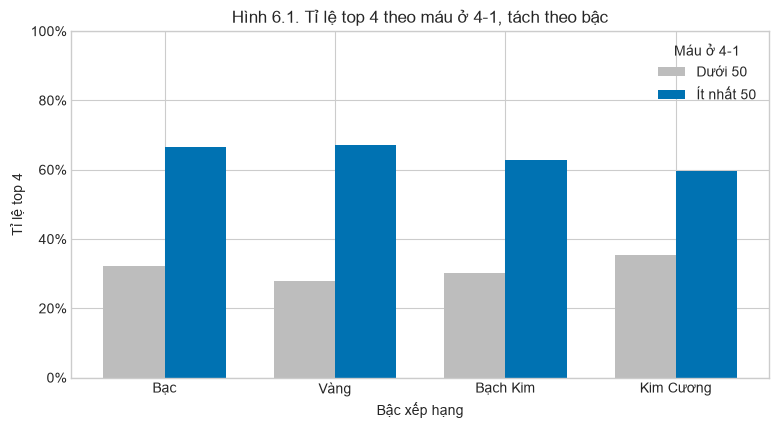

In [34]:
fig, ax = plt.subplots(figsize=(9, 4.5))
nhom = ["Dưới 50", "Ít nhất 50"]
x = np.arange(len(BAC))
width = 0.36

for j, nhom_mau in enumerate(nhom):
    d = (
        phan_tich_mau_theo_bac[
            phan_tich_mau_theo_bac["nhom_mau"] == nhom_mau
        ]
        .set_index("bac_xep_hang")
        .reindex(BAC)
    )
    ax.bar(
        x + (j - 0.5) * width,
        d["ti_le_top4"],
        width=width,
        label=nhom_mau,
        color=["#BDBDBD", "#0072B2"][j],
    )

ax.set(
    title="Hình 6.1. Tỉ lệ top 4 theo máu ở 4-1, tách theo bậc",
    xlabel="Bậc xếp hạng",
    ylabel="Tỉ lệ top 4",
    xticks=x,
    xticklabels=BAC,
    ylim=(0, 1),
)
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.legend(title="Máu ở 4-1")
plt.show()


<details><summary>Đọc kết quả</summary>

Các trận còn nhiều máu thường có kết quả tốt hơn, kể cả khi tách theo bậc. Tuy nhiên đây vẫn là dữ liệu quan sát:

- kỹ năng người chơi có thể làm cả máu ở 4-1 và placement tốt hơn;
- lõi, cửa hàng, đồ, chiến thuật và nhịp lobby cùng ảnh hưởng cả hai;
- “chủ động đặt một người ở 50 máu” không phải can thiệp có thể thực hiện độc lập với diễn biến trước đó.

Điều kiện hóa làm phép so sánh cụ thể hơn, nhưng không tự động tạo ra phản thực cần cho kết luận nhân quả.

</details>

### 6.2 Bài tự thiết kế

> **W03-TFT-CH02.** Chọn một câu hỏi dưới đây và thiết kế một pipeline cùng một biểu đồ:
>
> 1. Trong lobby nhanh, loại lõi nào đi cùng tỉ lệ top 4 cao nhất?
> 2. Số lần scout liên hệ với placement có giống nhau giữa các bậc không?
> 3. Mối liên hệ giữa vàng và placement có khác giữa Reroll, Tempo và Fast 8 không?
>
> Bài làm phải ghi rõ: đơn vị quan sát, phép lọc, biến nhóm, thống kê, ánh xạ và dạng hình học. Kết luận chỉ được dùng ngôn ngữ **liên hệ**, không dùng “gây ra”.


### 6.3 Tình huống tổng hợp: scout và kết quả trận

Câu hỏi: *Trong các hàng có telemetry, tần suất scout đi cùng tỉ lệ top 4 như thế nào?*

Quy trình:

1. Loại các hàng thiếu đúng biến cần dùng.
2. Tạo ba nhóm scout.
3. Nhóm và báo cáo cả `n` lẫn tỉ lệ.
4. Vẽ biểu đồ với trục tỉ lệ đầy đủ.
5. Diễn giải như một mối liên hệ quan sát.


In [35]:
case_scout = (
    tran_tft
    .dropna(subset=["so_lan_scout"])
    .assign(
        nhom_scout=lambda d: pd.cut(
            d["so_lan_scout"],
            bins=[-0.1, 1, 3, np.inf],
            labels=["0–1 lần", "2–3 lần", "Từ 4 lần"],
        )
    )
    .groupby("nhom_scout", observed=True)
    .agg(
        n=("top4", "size"),
        ti_le_top4=("top4", "mean"),
        placement_tb=("placement", "mean"),
    )
    .reset_index()
)
case_scout


,nhom_scout,n,ti_le_top4,placement_tb
0,0–1 lần,337,0.445,4.789
1,2–3 lần,349,0.479,4.544
2,Từ 4 lần,236,0.619,3.996


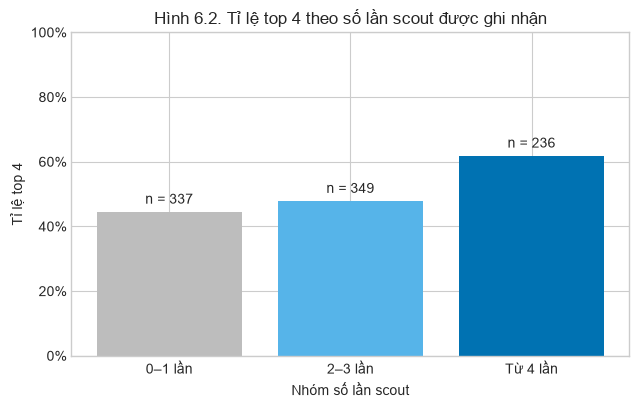

In [36]:
fig, ax = plt.subplots(figsize=(7.2, 4.2))
bars = ax.bar(
    case_scout["nhom_scout"].astype(str),
    case_scout["ti_le_top4"],
    color=["#BDBDBD", "#56B4E9", "#0072B2"],
)
for bar, n in zip(bars, case_scout["n"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.025,
        f"n = {n}",
        ha="center",
    )
ax.set(
    title="Hình 6.2. Tỉ lệ top 4 theo số lần scout được ghi nhận",
    xlabel="Nhóm số lần scout",
    ylabel="Tỉ lệ top 4",
    ylim=(0, 1),
)
ax.yaxis.set_major_formatter(PercentFormatter(1))
plt.show()


<details><summary>Diễn giải mẫu</summary>

Trong dữ liệu mô phỏng có telemetry, nhóm scout nhiều có tỉ lệ top 4 cao hơn và placement trung bình tốt hơn. Đây là **liên hệ**, không phải bằng chứng rằng bấm scout thêm sẽ tự nó gây ra top 4. Kỹ năng, bậc xếp hạng, thời lượng sống sót trong trận và cơ chế thiếu telemetry đều có thể góp phần tạo ra khác biệt.

</details>


---
## Tổng kết

**Những điều mang theo sau Tuần 03**

1. Một biểu đồ TFT vẫn có thể phân tích thành data, mappings, geometry và groups/facets.
2. Ánh xạ màu theo chiến thuật mang thông tin; đặt mọi điểm cùng màu chỉ là thiết lập.
3. Đường nối chỉ hợp lý khi các quan sát có thứ tự thật, như lịch sử nhiều trận của cùng một người chơi.
4. Lọc giữ đúng phạm vi câu hỏi; nhóm thay đổi cách tóm tắt được áp dụng.
5. Trung bình của biến `top4` logic là tỉ lệ top 4.
6. Số đếm, tỉ lệ gộp và tỉ lệ có điều kiện trả lời các câu hỏi khác nhau.
7. Nghịch lý Simpson trong ví dụ TFT xuất hiện vì cơ cấu lobby tạo ra các trọng số rất khác.
8. Điều kiện hóa có thể làm lộ cấu trúc bị trộn lẫn, nhưng không tự động chứng minh quan hệ nhân quả.
9. Mọi kết quả trong notebook chỉ mô tả **dữ liệu mô phỏng**, không phải meta của TFT thật.

> **Câu hỏi cuối buổi.** Một bảng thống kê cho thấy chiến thuật A có tỉ lệ top 4 gộp cao hơn chiến thuật B. Trước khi khuyên người chơi đổi chiến thuật, hãy nêu ít nhất bốn điều cần kiểm tra.

<details><summary>Một câu trả lời tốt</summary>

- Hai chiến thuật có được dùng ở cùng bậc và cùng nhịp lobby không?
- Cỡ mẫu của từng nhóm là bao nhiêu?
- Kết luận có giữ nguyên khi điều kiện hóa theo bậc, nhịp lobby hoặc loại lõi không?
- Đơn vị quan sát có độc lập không, hay nhiều trận đến từ cùng người chơi?
- Dữ liệu được chọn và đo như thế nào?
- Đây là liên hệ quan sát hay có một thiết kế cho phép nói về tác động nhân quả?

</details>
